# Zadanie domowe 3
### Autor: Kacper Łączyński

In [17]:
import numpy as np
import pandas as pd
import yfinance as yf

ticker = 'PKO.WA'
data_poczatkowa = '2025-04-27'
data_koncowa = '2026-04-28'
dane = yf.download(ticker, start=data_poczatkowa, end=data_koncowa, progress=False)

ceny_zamkniecia = dane['Close'].squeeze()
liczba_dni = len(ceny_zamkniecia)
S_t = float(ceny_zamkniecia.iloc[-1])

stopy_log = np.log(ceny_zamkniecia / ceny_zamkniecia.shift(1)).dropna()
sigma = float(stopy_log.std() * np.sqrt(252))

# Zaokrąglanie najnowszej ceny do pełnych złotych. To nasza cena wykonania opcji At-The-Money
K = round(S_t)
# Czas trwania opcji - 6 miesięcy
T = 0.5
# Rynkowa stopa referencyjna WIBOR 6M (z dnia 27.04.2026)
r_6m = 0.0390

print(f"--- PARAMETRY WEJŚCIOWE DO WYCENY ---")
print(f"Analizowana akcja: {ticker}")
print(f"Dane historyczne: od {data_poczatkowa} do {data_koncowa}")
print(f"Pobrano dane z {liczba_dni} dni sesyjnych.")
print(f"Cena spot (S_t): \t\t{S_t:.2f} PLN")
print(f"Cena wykonania (K): \t\t{K:.2f} PLN (Opcja At-The-Money)")
print(f"Czas do wygasania (T): \t\t{T} roku (6 miesięcy)")
print(f"Zmienność roczna (sigma): \t{sigma:.2%}")
print(f"Stopa wolna od ryzyka (r): \t{r_6m:.2%} (WIBOR 6M z 27.04.2026)")

--- PARAMETRY WEJŚCIOWE DO WYCENY ---
Analizowana akcja: PKO.WA
Dane historyczne: od 2025-04-27 do 2026-04-28
Pobrano dane z 249 dni sesyjnych.
Cena spot (S_t): 		96.86 PLN
Cena wykonania (K): 		97.00 PLN (Opcja At-The-Money)
Czas do wygasania (T): 		0.5 roku (6 miesięcy)
Zmienność roczna (sigma): 	30.73%
Stopa wolna od ryzyka (r): 	3.90% (WIBOR 6M z 27.04.2026)


### 1. Import danych oraz zdefiniowanie potrzebnych zmiennych:

Powyższym kodem przygotowałem potrzebne mi dane oraz zdefiniowałem zmienne, dzięki którym w późniejszym czasie mogłem obliczyć ceny opcji call i put.

#### Co zrobiłem w powyższym kodzie:
- Wybrałem akcje PKO.WA.
- Zaimportowałem dane historyczne za okres jednego roku. Ustawiłem datę końcową na 28.04.2026, aby mieć pewność, że program pobierze dane do 27.04 włącznie.
- Użyłem **.squeeze()**, aby zamienić tabelę dwuwymiarową w zwykłą liste. Bez tego program nie działał poprawnie w dalszej części.
- Wyznaczyłem cenę spot **S_t** jako ostatnią cenę zamknięcia (czyli tą z dnia 27.04.2026).
- Policzyłem logarytmiczne dzienne stopy zwrotu dla moich danych.
- Policzyłem dzienne odchylenie standardowe z tych logarytmicznych stóp zwrotu, a następnie przemnożyłem je przez **pierwiastek z 252**, aby je zannualizować, czyli sprowadzić do wartości rocznej. Użyłem **252** dni, a nie rzeczywistych **249**, aby zachować rynkowy standard.
- Zdefiniowałem cenę wykonania opcji **K** poprzez zaokrąglenie najnowszej ceny akcji do pełnych złotych. Dzięki temu wyceniam opcję typu At-The-Money.
- Zdefiniowałem czas do wygasania opcji **T** jako ułamek roku (6 miesięcy = **0.5** roku).
- Ustaliłem stopę wolną od ryzyka **r** w wysokości **3,90%**, co odpowiada rzeczywistej stawce WIBOR 6M z dnia 27.04.2026.

In [18]:
from scipy.stats import norm

# Nasze zmienne: S_t, K, T, r_6m, sigma

# 1. Obliczanie wartości pośrednich d1 i d2 zgodnie ze wzorem
d1 = (np.log(S_t / K) + (r_6m + ((sigma**2) / 2)) * T) / (sigma * np.sqrt(T))
d2 = d1 - (sigma * np.sqrt(T))

# 2. Wartość bieżąca ceny wykonania PV(K)
PV_K = K * np.exp(-r_6m * T)

# 3. Wycena opcji zakupu (CALL)
# Funkcja norm.cdf() to odpowiednik matematycznego N(), czyli skumulowanej funkcji dystrybucji
C_bs = norm.cdf(d1) * S_t - norm.cdf(d2) * PV_K

# 4. Wycena opcji sprzedaży (PUT)
P_bs = norm.cdf(-d2) * PV_K - norm.cdf(-d1) * S_t
P_bs1 = K * np.exp(-r_6m * T) - S_t + C_bs


# 5. Wyświetlenie wyników w formie raportu (Zgodnie z poleceniem)
print("--- RAPORT Z WYCENY BLACKA-SCHOLESA ---")
print(f"Wartość pośrednia d1: \t{d1:.4f}")
print(f"Wartość pośrednia d2: \t{d2:.4f}")
print("-" * 42)
print(f"Cena teoretyczna opcji CALL: \t{C_bs:.4f} PLN")
print(f"Cena teoretyczna opcji PUT: \t{P_bs:.4f} PLN")
print(f"Cena teoretyczna opcji PUT (drugi wzór): \t{P_bs1:.4f} PLN")

--- RAPORT Z WYCENY BLACKA-SCHOLESA ---
Wartość pośrednia d1: 	0.1917
Wartość pośrednia d2: 	-0.0256
------------------------------------------
Cena teoretyczna opcji CALL: 	9.2004 PLN
Cena teoretyczna opcji PUT: 	7.4672 PLN
Cena teoretyczna opcji PUT (drugi wzór): 	7.4672 PLN


### 2. Wycena opcji europejskich za pomocą modelu Blacka-Scholesa:

W tym kroku wykorzystałem zdefiniowane na warsztatach parametry rynkowe do analitycznej wyceny opcji call i put, posługując się klasycznym wzorem matematycznym Blacka-Scholesa. 

#### Co zrobiłem w powyższym kodzie:
- Zaimportowałem funkcję **norm** z biblioteki **scipy.stats**, która w moim kodzie pełni rolę skumulowanej funkcji dystrybucji rozkładu normalnego.
- Obliczyłem wartości pośrednie **d1** oraz **d2**.
- Obliczyłem wartość bieżącą ceny wykonania **PV_K**.
- Wyliczyłem teoretyczną cenę opcji kupna (**C_bs**), wykorzystując wzór z warsztatów.
- Wyliczyłem teoretyczne ceny opcji sprzedaży (**P_bs**) i (**P_bs1**), aby pokazać że oba wzory podane na warsztatach dadzą nam ten sam wynik.
- Na koniec wyświetliłem raport końcowy, który prezentuje wyliczone parametry oraz ostateczne ceny.

#### Interpretacja uzyskanych wyników:
- Parametry pośrednie **d1** i **d2**, wyniosły odpowiednio **0.1917** oraz **-0.0256**.
- Teoretyczna cena rynkowa dla opcji **CALL** wyniosła **9.2004 PLN**. W zaokrągleniu **9.20 PLN**.
- Teoretyczna cena dla opcji **PUT** wyniosła **7.4672 PLN**. W zaokrągleniu **7.47 PLN** 


In [19]:
import numpy as np

def wycena_monte_carlo(S, K, T, r, sigma, liczba_scenariuszy, seed=42):

    np.random.seed(seed)
    
    # 1. Losowanie Z z rozkładu normalnego standardowego N(0,1)
    # Od razu losujemy całą pulę za jednym zamachem.
    Z = np.random.standard_normal(liczba_scenariuszy)
    
    # 2. Symulacja ceny akcji na koniec okresu (S_T) za pomocą wzoru na Geometryczny Ruch Browna
    S_T = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    # 3. Obliczanie wypłaty z opcji (Payoff) na dzień wygaśnięcia
    wyplata_call = np.maximum(S_T - K, 0)
    wyplata_put = np.maximum(K - S_T, 0)
    
    # 4. Dyskontowanie średniej wypłaty do dzisiejszej wartości pieniądza
    czynnik_dyskontowy = np.exp(-r * T)
    C_mc = czynnik_dyskontowy * np.mean(wyplata_call)
    P_mc = czynnik_dyskontowy * np.mean(wyplata_put)
    
    return C_mc, P_mc

# Wycena dla 10 000 scenariuszy
C_mc_10k, P_mc_10k = wycena_monte_carlo(S_t, K, T, r_6m, sigma, 10000)

# Wycena dla 50 000 scenariuszy
C_mc_50k, P_mc_50k = wycena_monte_carlo(S_t, K, T, r_6m, sigma, 50000)

print("--- RAPORT Z WYCENY MONTE CARLO ---")
print("-" * 42)
print("Wyniki dla 10 000 scenariuszy:")
print(f"Cena opcji CALL: \t{C_mc_10k:.4f} PLN")
print(f"Cena opcji PUT: \t{P_mc_10k:.4f} PLN")
print("-" * 42)
print("Wyniki dla 50 000 scenariuszy:")
print(f"Cena opcji CALL: \t{C_mc_50k:.4f} PLN")
print(f"Cena opcji PUT: \t{P_mc_50k:.4f} PLN")

--- RAPORT Z WYCENY MONTE CARLO ---
------------------------------------------
Wyniki dla 10 000 scenariuszy:
Cena opcji CALL: 	9.2019 PLN
Cena opcji PUT: 	7.4975 PLN
------------------------------------------
Wyniki dla 50 000 scenariuszy:
Cena opcji CALL: 	9.1931 PLN
Cena opcji PUT: 	7.4696 PLN


### 3. Wycena opcji metodą symulacji Monte Carlo:

W powyższym kodzie wykonałem numeryczne wyceny opcji za pomocą symulacji Monte Carlo.

#### Co zrobiłem w powyższym kodzie:
- Stworzyłem funkcję **`wycena_monte_carlo`**, która odpowiada za cały proces symulacji.
- Zablokowałem ziarno losowości (**`seed=42`**), aby wyniki były powtarzalne przy każdym uruchomieniu kodu.
- Użyłem **wektoryzacji** NumPy do jednoczesnego wylosowania wszystkich zmiennych **Z**, eliminując powolne pętle for i drastycznie przyspieszając kod.
- Wykorzystałem model **Geometrycznego Ruchu Browna (GBM)** w formie zredukowanej (skokowej). Ponieważ dla opcji europejskich liczy się wyłącznie cena w dniu wygasania.
- Wyliczyłem wartość wewnętrzną opcji (Payoff) na koniec okresu dla każdej wylosowanej ścieżki z osobna, posługując się funkcją `np.maximum()`.
- Obliczyłem wartość oczekiwaną wypłaty z opcji, a następnie zdyskontowałem ją do dzisiejszej wartości pieniądza (PV) przy pomocy ciągłej stopy dyskontowej.
- Przeprowadziłem symulację dla dwóch różnych wielkości próby, **10 000** oraz **50 000** scenariuszy.

#### Interpretacja uzyskanych wyników:
- **Dla 10 000 scenariuszy:** opcja CALL = 9.2019 PLN | opcja PUT = 7.4975 PLN
- **Dla 50 000 scenariuszy:** opcja CALL = 9.1931 PLN | opcja PUT = 7.4696 PLN

Różnice w wynikach pomiędzy pierwszą a drugą symulacją wynikają wprost z natury procesów stochastycznych. Zgodnie z Mocnym Prawem Wielkich Liczb i Centralnym Twierdzeniem Granicznym, skok do 50 000 iteracji drastycznie redukuje wariancję błędu. Warto zauważyć że podczas gdy przy opcji PUT większa próba drastycznie przybliżyła wynik do wyniku teoretycznego (z 7.49 na 7.46 PLN), to przy opcji CALL wynik dla 10 000 ścieżek znalazł się bliżej prawdy wyłącznie przez przypadkowe ułożenie losowego ziarna. Większa pula 50 000 scenariuszy eliminuje te anomalie, dając znacznie bardziej stabilny i wiarygodny statystycznie obraz wyceny.

In [20]:
# 4. ZESTAWIENIE WYNIKÓW I ANALIZA RÓŻNIC

dane_porownawcze = {
    'Typ Opcji': ['CALL', 'CALL', 'PUT', 'PUT'],
    'Metoda Monte Carlo': ['10 000 ścieżek', '50 000 ścieżek', '10 000 ścieżek', '50 000 ścieżek'],
    'Cena Black-Scholes': [C_bs, C_bs, P_bs, P_bs],
    'Cena Monte Carlo': [C_mc_10k, C_mc_50k, P_mc_10k, P_mc_50k]
}

df_wyniki = pd.DataFrame(dane_porownawcze)

# Obliczamy różnicę absolutną (bezwzględną) w PLN: |MC - BS|
df_wyniki['Różnica Absolutna (PLN)'] = np.abs(df_wyniki['Cena Monte Carlo'] - df_wyniki['Cena Black-Scholes'])

# Obliczamy różnicę względną (procentową): |MC - BS| / BS
df_wyniki['Różnica Względna (%)'] = (df_wyniki['Różnica Absolutna (PLN)'] / df_wyniki['Cena Black-Scholes'])

print("--- 4. PORÓWNANIE: BLACK-SCHOLES vs MONTE CARLO ---")
display(df_wyniki.style.format({
    'Cena Black-Scholes': '{:.4f}',
    'Cena Monte Carlo': '{:.4f}',
    'Różnica Absolutna (PLN)': '{:.4f}',
    'Różnica Względna (%)': '{:.2%}'
}))

--- 4. PORÓWNANIE: BLACK-SCHOLES vs MONTE CARLO ---


,Typ Opcji,Metoda Monte Carlo,Cena Black-Scholes,Cena Monte Carlo,Różnica Absolutna (PLN),Różnica Względna (%)
0,CALL,10 000 ścieżek,9.2004,9.2019,0.0016,0.02%
1,CALL,50 000 ścieżek,9.2004,9.1931,0.0073,0.08%
2,PUT,10 000 ścieżek,7.4672,7.4975,0.0303,0.41%
3,PUT,50 000 ścieżek,7.4672,7.4696,0.0024,0.03%


### 4. Zestawienie wyników i analiza błędów:

W tym etapie przedstawiłem wyniki wyliczania cen opcji call i put z obu metod w jednej przejrzystej tabeli aby je ze sobą porównać. 

#### Co zrobiłem w powyższym kodzie:
- Wykorzystałem bibliotekę **Pandas** do stworzenia tabeli, zestawiając wyceny z obu modeli dla 10 000 i 50 000 scenariuszy.
- Wyliczyłem **różnicę absolutną (PLN)** przy pomocy funkcji wartości bezwzględnej `np.abs()`.
- Wyliczyłem **różnicę względną (%)**, dzieląc błąd absolutny przez cenę Black-Scholesa.

#### Interpretacja uzyskanych wyników i wnioski:

##### **Czy wyniki są podobne?**

Na podstawie tabeli z wynikami, możemy zauważyć że uzyskane obiema metodami wyniki są niemal identyczne. Różnice absolutne dla **50 000** ścieżek są w granicach **ułamków groszy** (odchylenie o 0.0073 PLN dla opcji CALL oraz 0.0024 PLN dla opcji PUT). Błąd względny w żadnym z symulowanych scenariuszy nie przekroczył **0.5%**, co świadczy że symulacja Monte Carlo poprawnie odwzorowywuje ścisłe wyniki teoretyczne. 

##### **Jak liczba ścieżek wpływa na dokładność?**

Tabela świetnie pokazuje, jak w praktyce działa metoda Monte Carlo. Zwiększenie puli z 10 000 do 50 000 scenariuszy generalnie zmniejsza margines błędu. Widać tu dwie rzeczy:
- **Spadek błędu (opcja PUT)**: Zwiększenie próby zadziałało tu perfekcyjnie. Pięciokrotnie większa liczba ścieżek sprawiła, że błąd spadł z 0.0303 PLN (0.41%) do zaledwie 0.0024 PLN (0.03%). Wynik stał się dużo bardziej precyzyjny.
- **Losowość wyników (opcja CALL):** Co ciekawe, dla opcji CALL przy 10 000 iteracji błąd był o włos mniejszy (0.02%) niż przy 50 000 (0.08%). To normalne zjawisko – przy mniejszej liczbie losowań po prostu mieliśmy odrobinę więcej "szczęścia" i wynik przypadkiem trafił bliżej celu. Jednak przy poważnej wycenie to model oparty na 50 000 ścieżek eliminuje takie przypadkowe zachowania i daje nam znacznie większą pewność.

# DODATEK:

In [21]:
# Funkcja gęstości rozkładu normalnego N'(d1)
pdf_d1 = norm.pdf(d1)

# 1. DELTA (Wrażliwość na zmianę ceny akcji o 1 PLN)
delta_call = norm.cdf(d1)
delta_put = norm.cdf(d1) - 1

# 2. GAMMA (Wrażliwość Delty na zmianę ceny - "przyspieszenie")
gamma = pdf_d1 / (S_t * sigma * np.sqrt(T))

# 3. VEGA (Wrażliwość na zmianę zmienności rynkowej o 1 punkt procentowy)
# Dzielimy Vegę przez 100, aby pokazywała zmianę na 1% zmienności.
vega = (S_t * pdf_d1 * np.sqrt(T)) / 100

# 4. THETA (Utrata wartości opcji z upływem czasu - dziennie)
# Dzielimy przez 252 (dni sesyjne), aby uzyskać spadek wartości na 1 dzień
theta_call = (-(S_t * pdf_d1 * sigma) / (2 * np.sqrt(T)) - r_6m * K * np.exp(-r_6m * T) * norm.cdf(d2)) / 252
theta_put = (-(S_t * pdf_d1 * sigma) / (2 * np.sqrt(T)) + r_6m * K * np.exp(-r_6m * T) * norm.cdf(-d2)) / 252

# Zestawienie w tabeli
dane_greki = {
    'Wskaźnik (Greka)': ['Delta', 'Gamma', 'Vega (na 1%)', 'Theta (dzienna)'],
    'Opcja CALL': [delta_call, gamma, vega, theta_call],
    'Opcja PUT': [delta_put, gamma, vega, theta_put]
}

df_greki = pd.DataFrame(dane_greki)

print("--- 5. ANALIZA WRAŻLIWOŚCI (ZARZĄDZANIE RYZYKIEM) ---")
display(df_greki.style.format({
    'Opcja CALL': '{:.4f}',
    'Opcja PUT': '{:.4f}'
}))

--- 5. ANALIZA WRAŻLIWOŚCI (ZARZĄDZANIE RYZYKIEM) ---


,Wskaźnik (Greka),Opcja CALL,Opcja PUT
0,Delta,0.5760,-0.4240
1,Gamma,0.0186,0.0186
2,Vega (na 1%),0.2683,0.2683
3,Theta (dzienna),-0.0399,-0.0252


### 5. Analiza wrażliwości – tzw. "Greki" (Zarządzanie ryzykiem)

#### Skąd wziąłem wzory i co zrobiłem w kodzie:

Do wyliczenia Greków użyłem oficjalnych wzorów z Wikipedii dla modelu Blacka-Scholesa. Zrobiłem tu jednak jedno bardzo ważne założenie. Przyjąłem, że parametr **q (czyli roczna stopa dywidendy dla indeksu) wynosi zero**. Dzięki temu wzory z Wikipedii mocno się upraszczają.

Dodatkowo w samym kodzie wprowadziłem dwie praktyczne poprawki:
- **Vegę** podzieliłem przez 100. Dzięki temu w tabeli widzę, jak zmieni się cena opcji, gdy rynkowa zmienność skoczy o 1 punkt procentowy.
- **Thetę** podzieliłem przez 252. Wzór matematyczny wyrzuca spadek wartości w skali całego roku, co jest mało intuicyjne. Podzielenie tego daje mi konkretną kwotę, jaką opcja traci każdego dnia.

#### Jak interpretuję uzyskane wyniki?

Moje wyniki dla PKO BP (opcja At-The-Money) wyglądają następująco:

1. **Delta (CALL: 0.5760 | PUT: -0.4240)**
Zgodnie z definicją z Wikipedii, Delta mówi o tym, jak zachowa się opcja przy zmianie ceny instrumentu bazowego o 1 zł. Z moich wyliczeń wynika, że jeśli PKO BP pójdzie złotówkę w górę, moja opcja CALL zyska na wartości ok. 58 groszy. Opcja PUT zachowa się odwrotnie – straci na wartości około 42 grosze.

2. **Gamma (0.0186 dla obu)**
Gamma to po prostu "przyspieszenie" dla Delty. Jeśli cena akcji wzrośnie o ten 1 zł, nasza Delta nie będzie stała w miejscu, ale powiększy się dodatkowo właśnie o 0.0186. Wynik jest identyczny dla opcji Call i Put.

3. **Vega (0.2683 dla obu)**
Vega pokazuje, ile zyskamy, jeśli pojawi się panika i zmienność skoczy w górę o 1%. W moim modelu wyszło, że taki wzrost zmienności podbije cenę mojej opcji o około 27 groszy.

4. **Theta dzienna (CALL: -0.0399 | PUT: -0.0252)**
Theta to "koszt uciekającego czasu" do wygaśnięcia. Moje wyniki pokazują twardą rzeczywistość: wystarczy, że minie jeden dzień, a moja opcja CALL traci prawie 4 grosze, natomiast PUT o około 2,5 grosza.

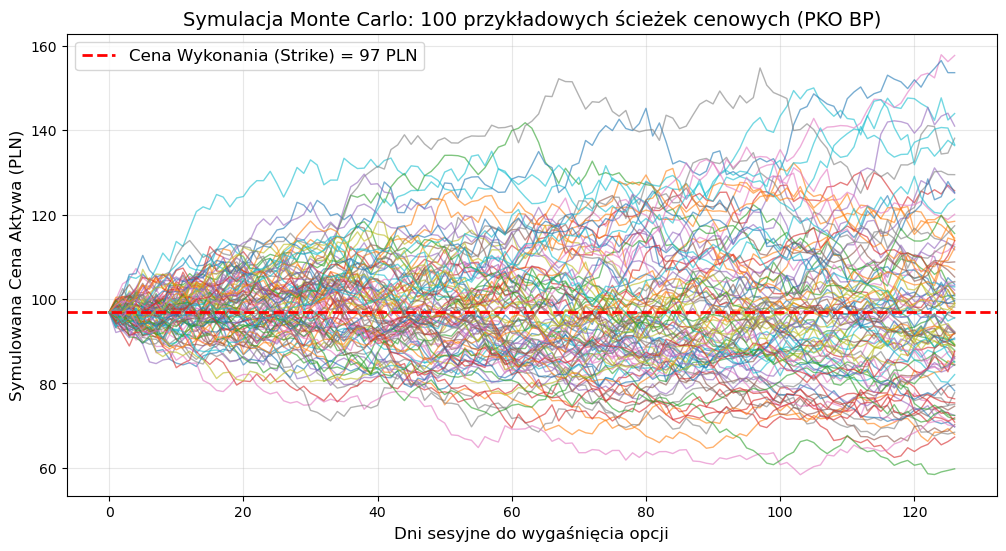

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def rysuj_proces_browna(S, K, T, r, sigma, liczba_sciezek=100, kroki=126):
    """
    Rysuje wybraną liczbę ścieżek symulacji krok po kroku (dyskretyzacja).
    126 kroków to ok. liczba dni sesyjnych w 6 miesięcy.
    """
    np.random.seed(42)
    dt = T / kroki
    
    # Inicjalizacja macierzy na ceny
    sciezki = np.zeros((kroki + 1, liczba_sciezek))
    sciezki[0] = S
    
    # Generowanie losowego szumu (Z)
    Z = np.random.standard_normal((kroki, liczba_sciezek))
    
    # Symulacja krok po kroku
    for t in range(1, kroki + 1):
        sciezki[t] = sciezki[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[t-1])
        
    # Rysowanie
    plt.figure(figsize=(12, 6))
    plt.plot(sciezki, linewidth=1, alpha=0.6)
    plt.axhline(y=K, color='red', linestyle='--', linewidth=2, label=f'Cena Wykonania (Strike) = {K} PLN')
    
    plt.title('Symulacja Monte Carlo: 100 przykładowych ścieżek cenowych (PKO BP)', fontsize=14)
    plt.xlabel('Dni sesyjne do wygaśnięcia opcji', fontsize=12)
    plt.ylabel('Symulowana Cena Aktywa (PLN)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

# Wywołanie funkcji rysującej (zmienne muszą być wcześniej zdefiniowane)
rysuj_proces_browna(S_t, K, T, r_6m, sigma)

### 6. Wizualizacja symulacji Monte Carlo:

Na sam koniec postanowiłem zwizualizować to, co do tej pory działo się wyłącznie w pamięci komputera. Wygenerowany wykres ilustracja tego, jak w praktyce działa metoda Monte Carlo oparta na Geometrycznym Ruchu Browna.

#### Jak czytać ten wykres w kontekście wyceny opcji?
Kluczowym elementem na wykresie jest **czerwona, przerywana linia**. To nasza cena wykonania (Strike), która oddziela strefę zysku od strefy straty.

Z punktu widzenia naszych opcji patrzymy wyłącznie na **prawą krawędź wykresu** (dzień wygaśnięcia):
- **Dla opcji CALL:** Interesują nas tylko te kolorowe linie, które zakończyły swój bieg **powyżej** czerwonej przerywanej linii. Tylko w tych scenariuszach opcja Call przynosi zysk (jest *In-The-Money*). Ścieżki kończące się poniżej oznaczają, że opcja wygasa bezwartościowa.
- **Dla opcji PUT:** Sytuacja jest odwrotna. Opcja Put zarabia w scenariuszach, w których rynek się załamuje, a kolorowe linie lądują na samym końcu **poniżej** czerwonej kreski.

#### Charakterystyczny kształt "lejka"
Warto też zwrócić uwagę na sam kształt wykresu. Wszystkie ścieżki wychodzą z jednego, znanego nam dziś punktu (obecna cena spot). Z każdym kolejnym dniem linie rozchodzą się jednak coraz szerzej, tworząc kształt poziomego lejka lub trąbki. To wizualny dowód na to, jak działa rynkowa zmienność – im dalej patrzymy w przyszłość, tym większa jest niepewność i tym szerszy wachlarz potencjalnych cen akcji. Nasz model uśrednia te wszystkie końcowe wyniki i dyskontuje je, dając nam ostateczną cenę opcji.